# Task 1
The dataset contains vegetation indices and spectral features extracted from crop fields. These features represent important information about crop health, chlorophyll content, water availability, canopy density, and overall vegetation condition. The target variable, **crop_health_label**, classifies each sample as either **Healthy** or **Stressed**. These vegetation indices serve as input features for multiple machine learning algorithms, including **Logistic Regression, Decision Tree, Random Forest, and Stochastic Gradient Descent (SGD) Classifier with 5-Fold Cross Validation**, to accurately identify and classify crop stress. The performance of these models is evaluated using metrics such as **Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Cross Validation** to determine the most effective model for crop health prediction.


### Role of Each Vegetation Index in Detecting Crop Stress

NDVI Mean (ndvi_mean)	:Measures overall vegetation health by comparing near-infrared (NIR) and red light reflectance. Higher NDVI values indicate healthy vegetation, while lower values suggest crop stress or poor growth.

NDVI Standard Deviation (ndvi_std):	Indicates variation in vegetation health within a field. High variation may reveal uneven crop growth or localized stress.

GNDVI (gndvi)	:Uses the green band instead of the red band to estimate chlorophyll concentration. It is sensitive to nitrogen deficiency and early plant stress.

SAVI (savi):	Minimizes the influence of soil brightness, making it useful for detecting crop stress in fields with sparse vegetation or exposed soil.

EVI (evi):	Enhances vegetation monitoring by reducing atmospheric and soil background effects. It is particularly effective in dense crop canopies and helps detect subtle stress conditions.

Red Edge 1 (red_edge_1):	Captures changes in chlorophyll content. It can detect crop stress before visible symptoms appear, making it useful for early stress monitoring.

Red Edge 2 (red_edge_2)	:Provides additional sensitivity to plant physiological changes and improves discrimination between healthy and stressed crops.

NIR Reflectance (nir_reflectance):	Healthy plants strongly reflect near-infrared light. Reduced NIR reflectance often indicates damaged leaves, water stress, or disease.

Moisture Index (moisture_index):	Estimates the water content of vegetation. Lower values indicate water deficiency or drought stress.

Canopy Density (canopy_density)	:**Represents** the density and coverage of the crop canopy. Lower canopy density may indicate poor growth, pest damage, or nutrient deficiency.

# Task 2

# LOGISTIC REGRESSION

In [ ]:
#logistic regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,classification_report
)

In [ ]:
#Loading dataset and creating a dataframe
input_file="crop_data.csv"
df=pd.read_csv(input_file)

In [ ]:
#splitting dataset into x and y
df.columns=['ndvi_mean','ndvi_std','ndvi_min','ndvi_max','gndvi','savi','evi','red_edge_1','red_edge_2','nir_reflectance','soil_brightness','canopy_density','moisture_index','grid_x','grid_y','crop_health_label']
x=df.drop("crop_health_label", axis=1)
y=df["crop_health_label"]

In [ ]:
#doing train_test_split the given data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#applying logistic regression to the model,training and predicting the model
model=LogisticRegression(max_iter=5000)
model.fit(x_train,y_train)
preds=model.predict(x_test)
confusion_matrix(y_test,preds)

array([[151,   5],
       [  6,  78]])

In [ ]:
#predictions
preds

array(['Healthy', 'Healthy', 'Healthy', 'Stressed', 'Stressed', 'Healthy',
       'Healthy', 'Stressed', 'Healthy', 'Stressed', 'Healthy',
       'Stressed', 'Stressed', 'Healthy', 'Healthy', 'Healthy', 'Healthy',
       'Healthy', 'Healthy', 'Healthy', 'Stressed', 'Healthy', 'Stressed',
       'Healthy', 'Healthy', 'Stressed', 'Healthy', 'Stressed', 'Healthy',
       'Stressed', 'Healthy', 'Healthy', 'Healthy', 'Healthy', 'Stressed',
       'Healthy', 'Healthy', 'Healthy', 'Healthy', 'Healthy', 'Healthy',
       'Healthy', 'Healthy', 'Healthy', 'Healthy', 'Stressed', 'Stressed',
       'Healthy', 'Healthy', 'Stressed', 'Healthy', 'Stressed', 'Healthy',
       'Healthy', 'Healthy', 'Stressed', 'Stressed', 'Healthy', 'Healthy',
       'Stressed', 'Stressed', 'Stressed', 'Healthy', 'Healthy',
       'Stressed', 'Healthy', 'Healthy', 'Healthy', 'Healthy', 'Healthy',
       'Healthy', 'Stressed', 'Healthy', 'Healthy', 'Stressed',
       'Stressed', 'Stressed', 'Stressed', 'Healthy', 'Stres

In [ ]:
accuracy_score(y_test,preds)


0.9541666666666667

In [ ]:
precision_score(y_test,preds,average='weighted')

0.9540748983193923

In [ ]:
recall_score(y_test,preds,average='weighted')

0.9541666666666667

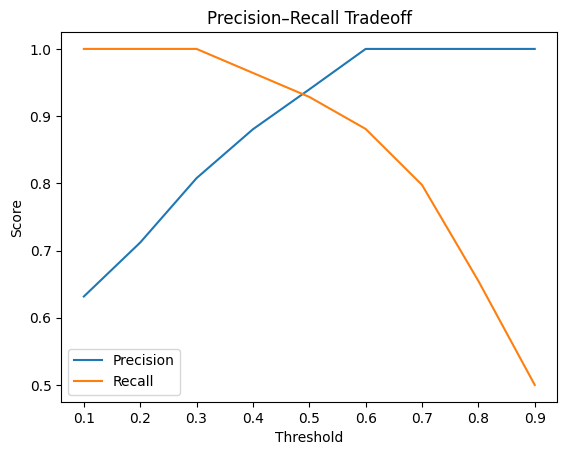

In [ ]:
probs = model.predict_proba(x_test)[:,1]

# Encode y_test to numerical labels to match the predictions (assuming 'Healthy': 0, 'Stressed': 1)
y_test_encoded = y_test.map({'Healthy': 0, 'Stressed': 1})

thresholds = np.linspace(0.1, 0.9, 9)
precisions, recalls = [], []

for t in thresholds:
    preds_t = (probs >= t).astype(int)
    precisions.append(precision_score(y_test_encoded, preds_t))
    recalls.append(recall_score(y_test_encoded, preds_t))

plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision–Recall Tradeoff')
plt.legend()
plt.show()

In [ ]:
f1_score(y_test,preds,average='weighted')

0.9541026573051979

In [ ]:
#classification report
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

     Healthy       0.96      0.97      0.96       156
    Stressed       0.94      0.93      0.93        84

    accuracy                           0.95       240
   macro avg       0.95      0.95      0.95       240
weighted avg       0.95      0.95      0.95       240



# Task 3

In [ ]:
# Create DataFrame with coordinates and predictions
heatmap_df = pd.DataFrame({
    "grid_x": x_test["grid_x"].values,
    "grid_y": x_test["grid_y"].values,
    "prediction": preds
})

In [ ]:
# Convert labels to numbers
heatmap_df["stress"] = heatmap_df["prediction"].map({
    "Healthy": 0,
    "Stressed": 1
})

In [ ]:
# Aggregate predictions into grid cells
field_grid = heatmap_df.pivot_table(
    index="grid_y",
    columns="grid_x",
    values="stress",
    aggfunc="mean"
)


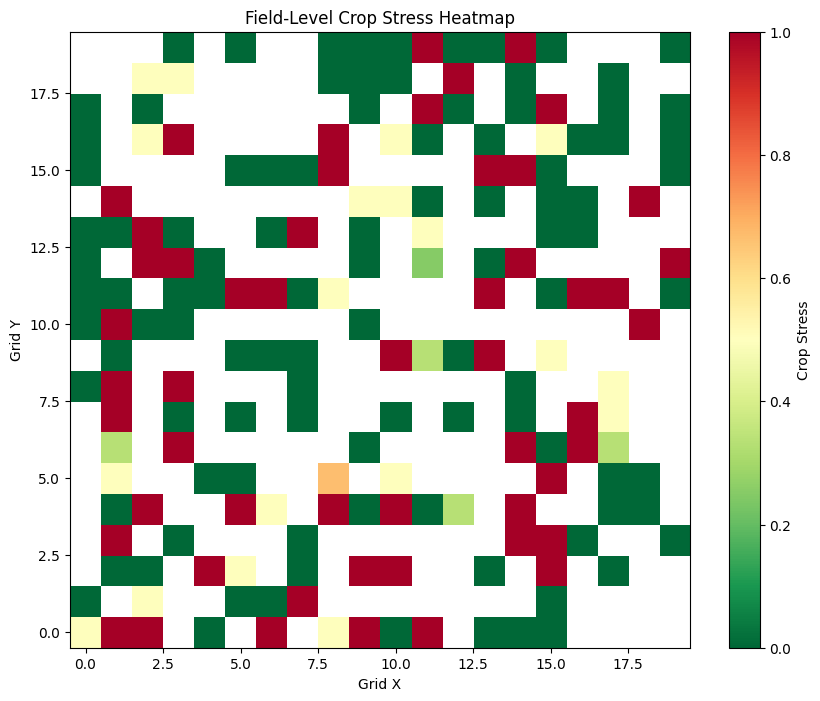

In [ ]:
# Plot heatmap
plt.figure(figsize=(10,8))
plt.imshow(field_grid, cmap="RdYlGn_r", origin="lower", aspect="auto")
plt.colorbar(label="Crop Stress")

plt.title("Field-Level Crop Stress Heatmap")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")

plt.show()

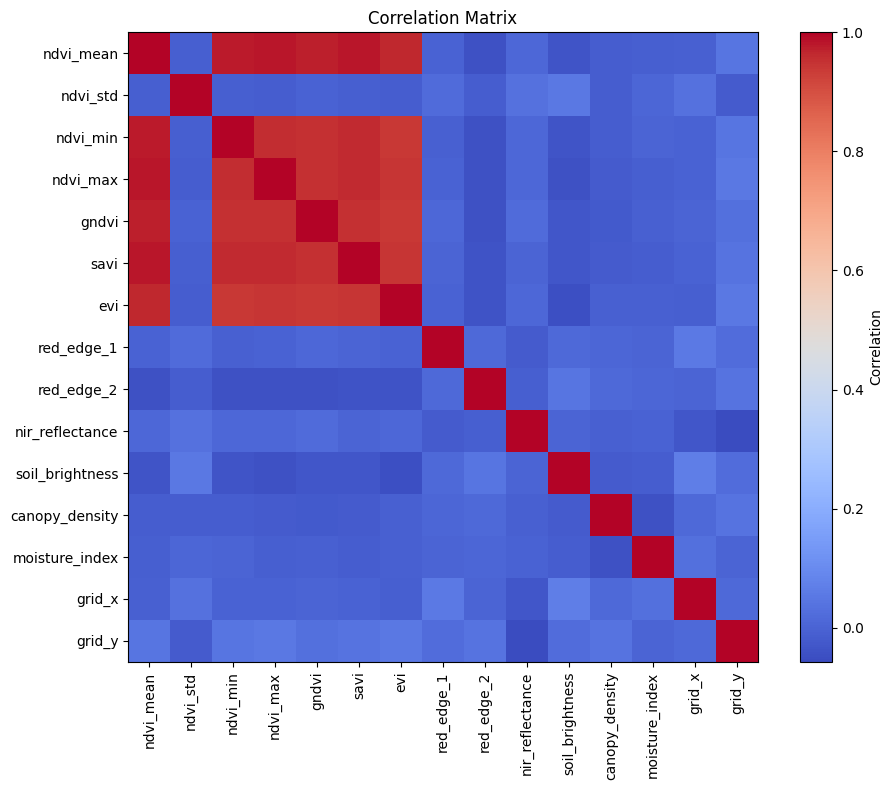

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')

plt.colorbar(label='Correlation')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

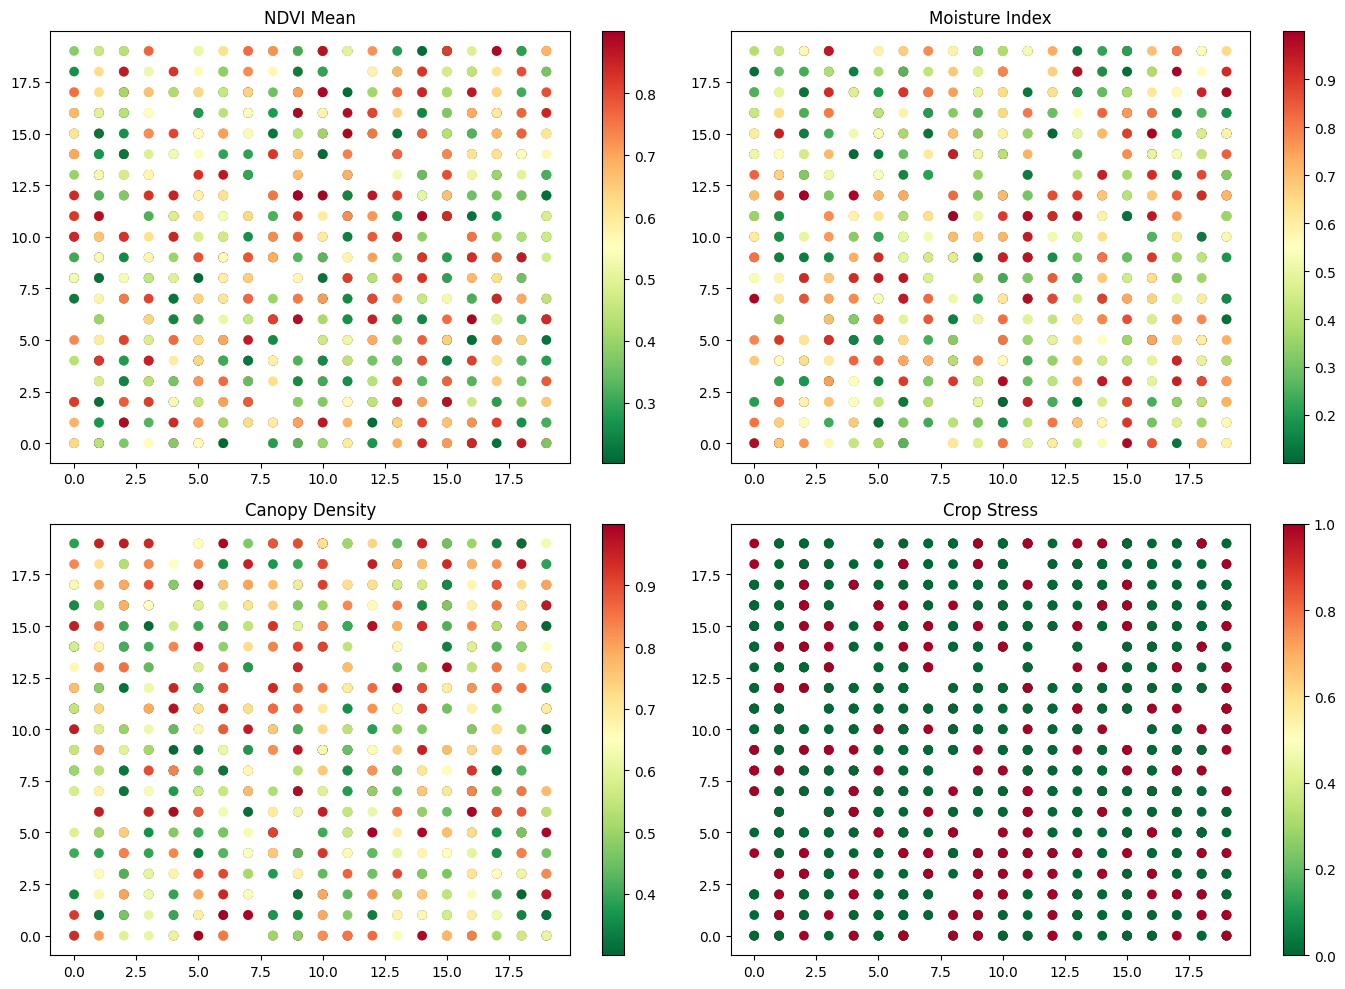

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))

# Map 'crop_health_label' to numerical values for plotting 'Crop_Stress'
df['crop_stress_numeric'] = df['crop_health_label'].map({'Healthy': 0, 'Stressed': 1})

features = ['ndvi_mean', 'moisture_index', 'canopy_density', 'crop_stress_numeric']
titles = ['NDVI Mean', 'Moisture Index', 'Canopy Density', 'Crop Stress']

for ax, feature, title in zip(axs.ravel(), features, titles):
    sc = ax.scatter(
        df['grid_x'],
        df['grid_y'],
        c=df[feature],
        cmap='RdYlGn_r' # RdYlGn_r means red for low, green for high. For stress (0=healthy, 1=stressed), this cmap is appropriate.
    )
    ax.set_title(title)
    plt.colorbar(sc, ax=ax)

plt.tight_layout()

plt.show()

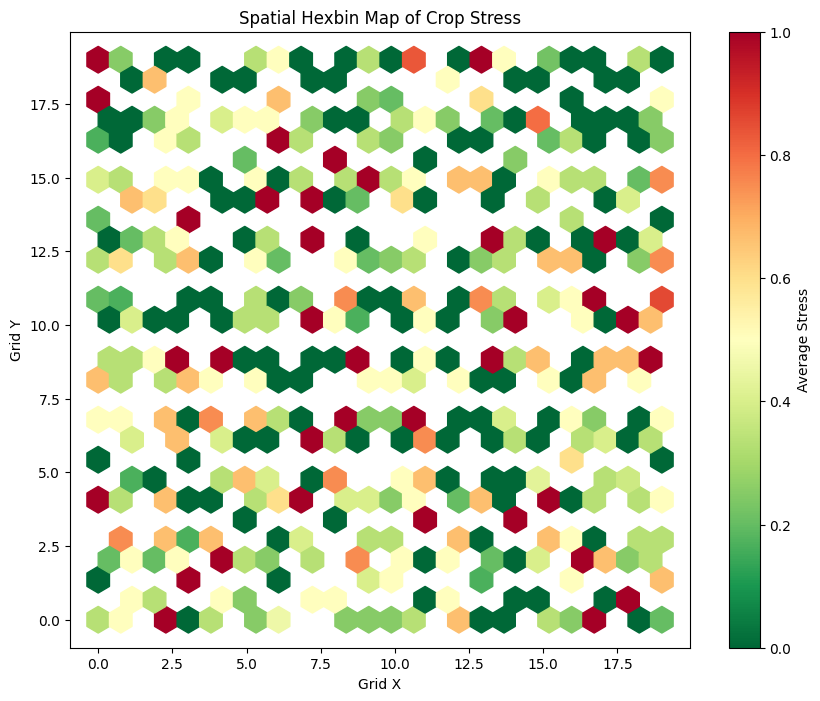

In [ ]:
plt.figure(figsize=(10,8))

plt.hexbin(
    df['grid_x'],
    df['grid_y'],
    C=df['crop_stress_numeric'],
    gridsize=25,
    reduce_C_function=np.mean,
    cmap='RdYlGn_r' # RdYlGn_r means red for low, green for high. For stress (0=healthy, 1=stressed), this cmap is appropriate.
)

plt.colorbar(label="Average Stress")

plt.title("Spatial Hexbin Map of Crop Stress")

plt.xlabel("Grid X")
plt.ylabel("Grid Y")

plt.show()

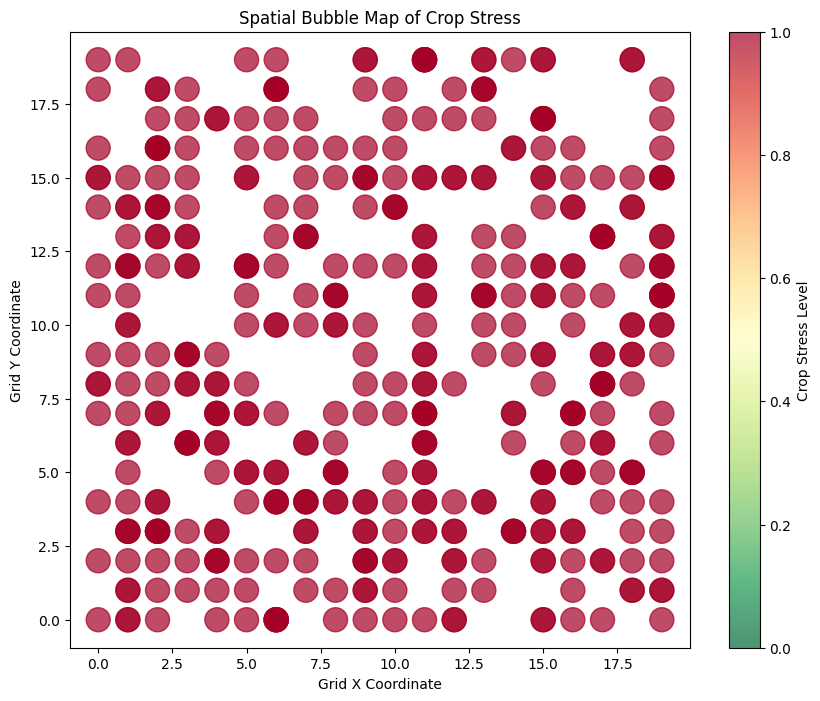

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    df['grid_x'],
    df['grid_y'],
    c=df['crop_stress_numeric'],
    s=df['crop_stress_numeric']*300, # Scale size by numerical stress
    cmap='RdYlGn_r', # RdYlGn_r means red for low, green for high. For stress (0=healthy, 1=stressed), this cmap is appropriate.
    alpha=0.7
)

plt.colorbar(label='Crop Stress Level')

plt.xlabel("Grid X Coordinate")
plt.ylabel("Grid Y Coordinate")
plt.title("Spatial Bubble Map of Crop Stress")

plt.show()

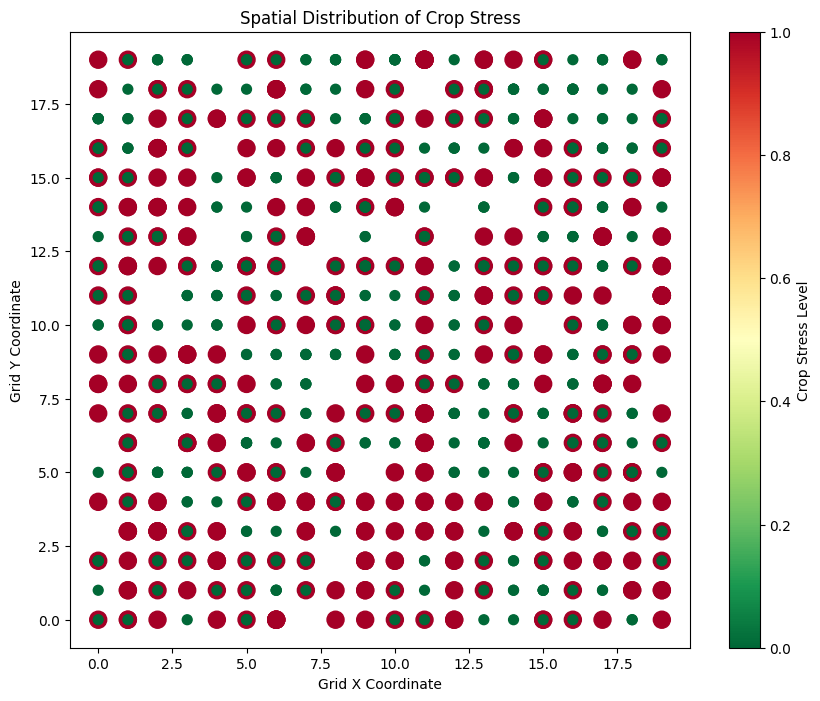

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(df['grid_x'], df['grid_y'],
            c=df['crop_stress_numeric'], # Use numerical stress for color
            cmap='RdYlGn_r', # RdYlGn_r means red for low, green for high. For stress (0=healthy, 1=stressed), this cmap is appropriate.
            s=df['crop_stress_numeric']*100 + 50) # Scale size by numerical stress, add a base size

plt.colorbar(label='Crop Stress Level')

plt.xlabel('Grid X Coordinate')
plt.ylabel('Grid Y Coordinate')
plt.title('Spatial Distribution of Crop Stress')

plt.show()

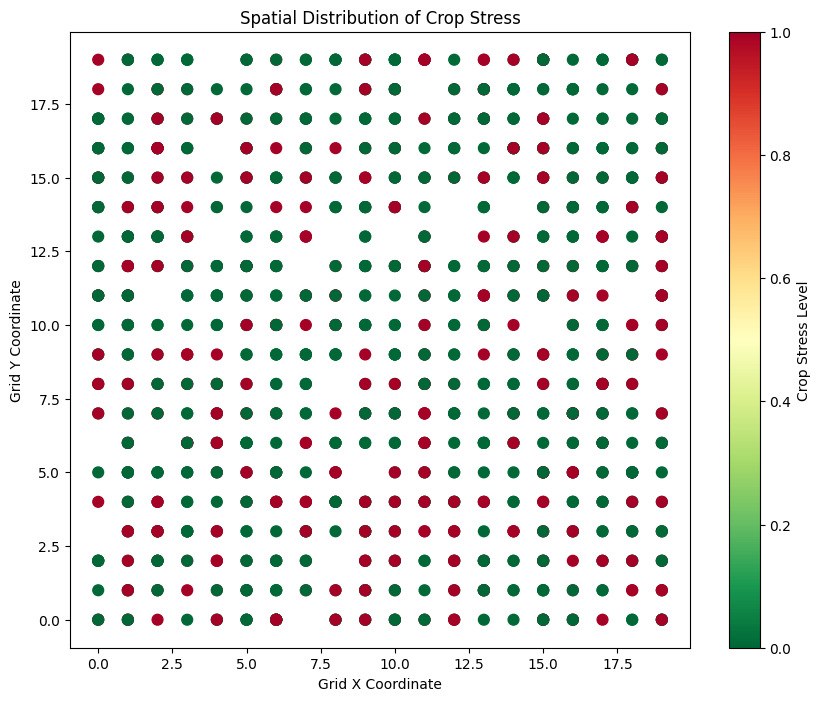

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    df['grid_x'],
    df['grid_y'],
    c=df['crop_stress_numeric'], # Use numerical stress for color
    cmap='RdYlGn_r', # RdYlGn_r means red for low, green for high. For stress (0=healthy, 1=stressed), this cmap is appropriate.
    s=60
)

plt.colorbar(label='Crop Stress Level')

plt.xlabel("Grid X Coordinate")
plt.ylabel("Grid Y Coordinate")
plt.title("Spatial Distribution of Crop Stress")

plt.show()

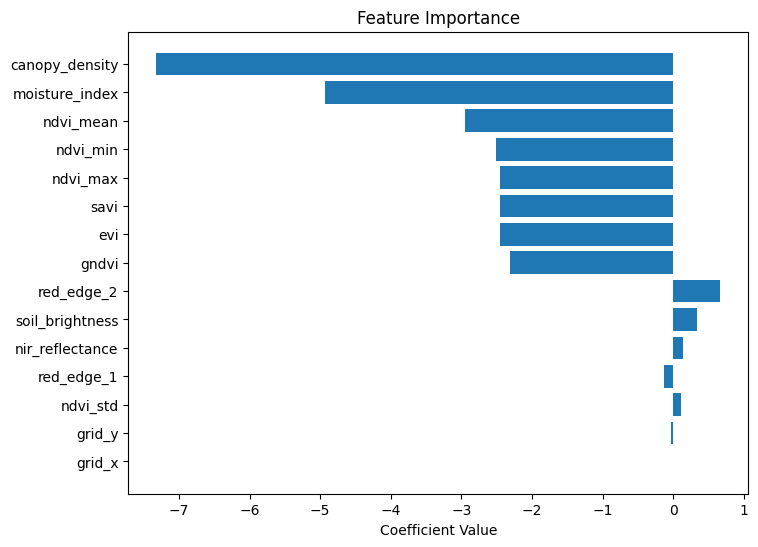

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

plt.figure(figsize=(8,6))

plt.barh(
    importance['Feature'],
    importance['Coefficient']
)

plt.xlabel("Coefficient Value")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

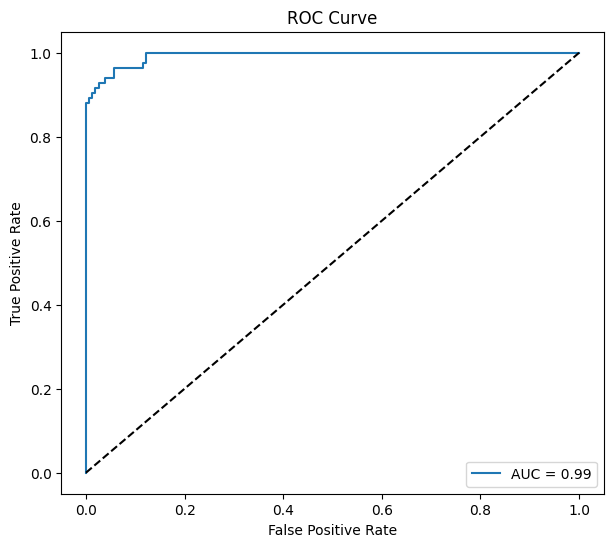

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test_encoded, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

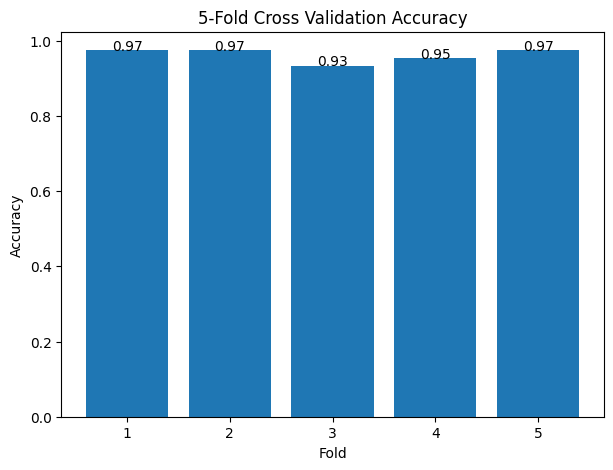

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    x,
    y,
    cv=5
)

plt.figure(figsize=(7,5))

plt.bar(
    range(1,6),
    scores
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Accuracy")

for i, score in enumerate(scores):
    plt.text(i+1, score, f"{score:.2f}", ha='center')

plt.show()

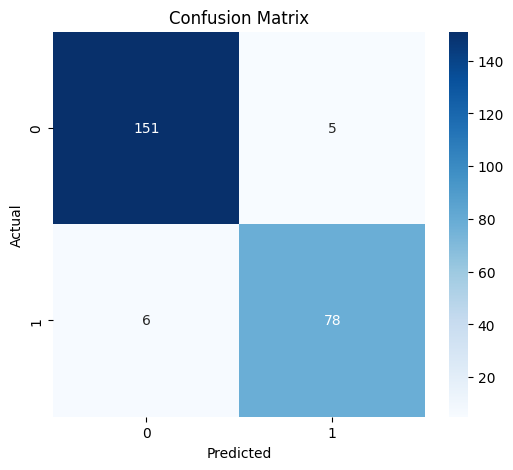

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

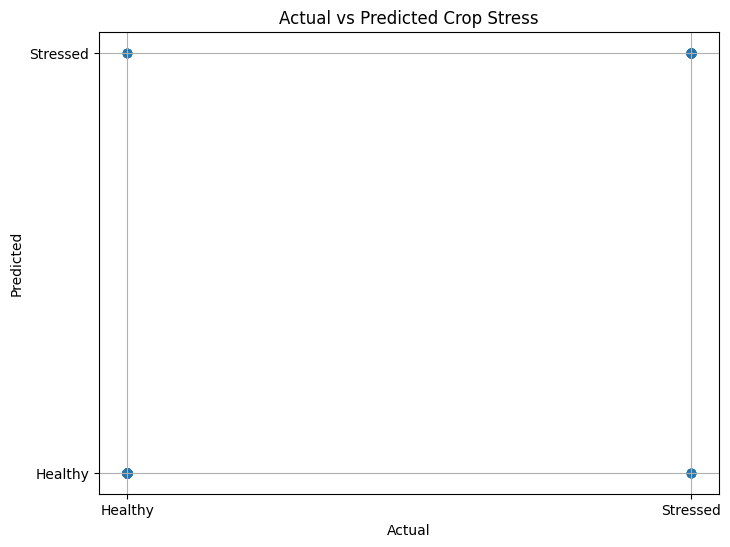

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    preds,
    alpha=0.7
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted Crop Stress")

plt.grid(True)

plt.show()

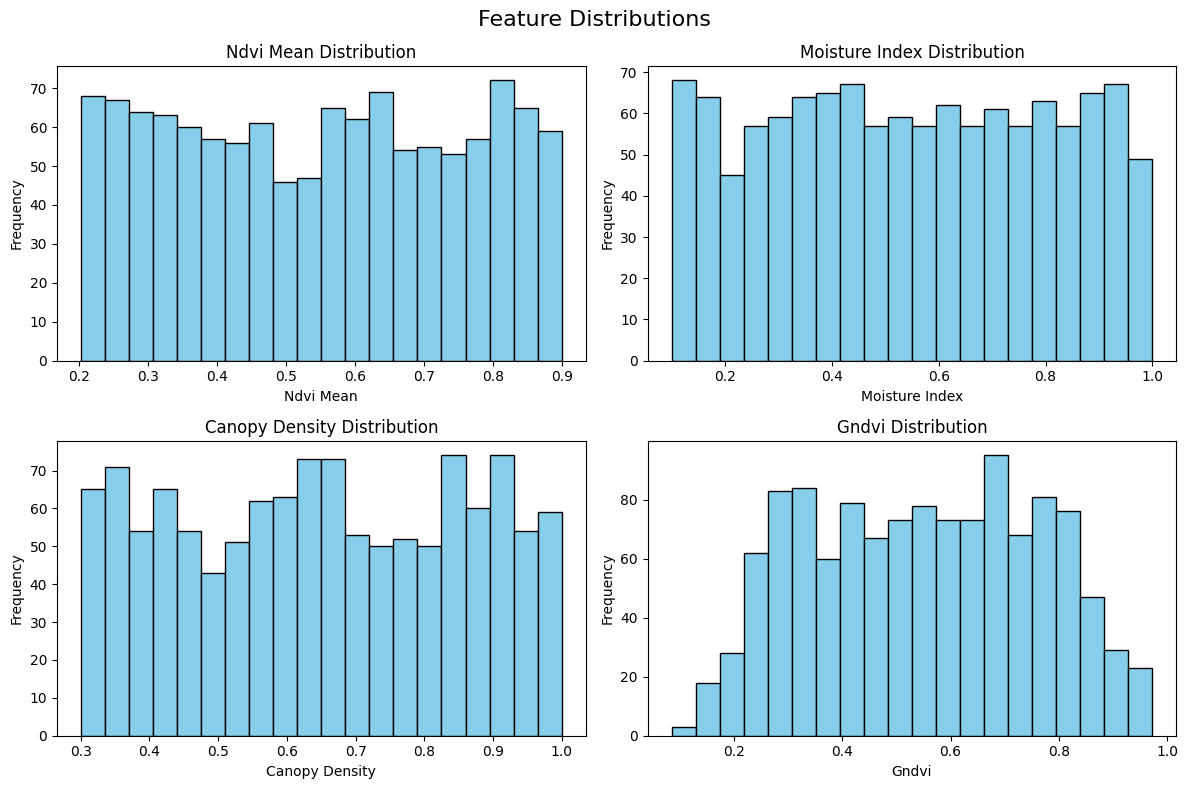

In [ ]:
import matplotlib.pyplot as plt

features = ['ndvi_mean', 'moisture_index', 'canopy_density', 'gndvi']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.ravel(), features):
    ax.hist(df[feature],
            bins=20,
            color='skyblue',
            edgecolor='black')

    ax.set_title(f'{feature.replace("_", " ").title()} Distribution')
    ax.set_xlabel(feature.replace("_", " ").title())
    ax.set_ylabel('Frequency')

plt.suptitle("Feature Distributions", fontsize=16)

plt.tight_layout()

plt.show()

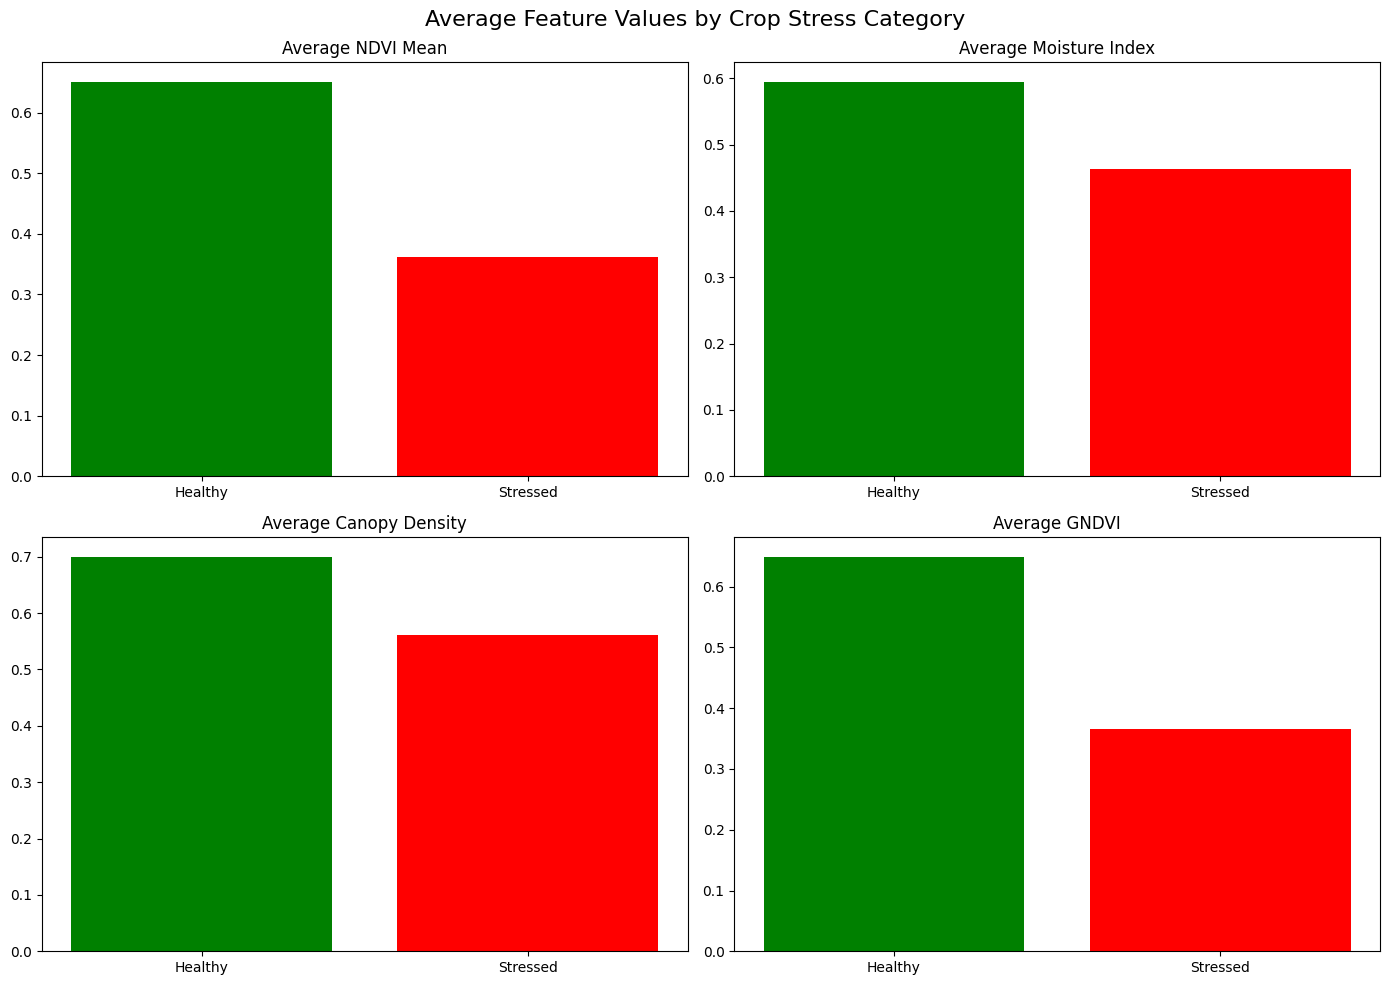

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Average NDVI
avg_ndvi = df.groupby('crop_health_label')['ndvi_mean'].mean()
axes[0,0].bar(avg_ndvi.index, avg_ndvi.values, color=['green','red'])
axes[0,0].set_title("Average NDVI Mean")

# Average Soil Moisture
avg_sm = df.groupby('crop_health_label')['moisture_index'].mean()
axes[0,1].bar(avg_sm.index, avg_sm.values, color=['green','red'])
axes[0,1].set_title("Average Moisture Index")

# Average Canopy Density (replacing Temperature)
avg_canopy_density = df.groupby('crop_health_label')['canopy_density'].mean()
axes[1,0].bar(avg_canopy_density.index, avg_canopy_density.values, color=['green','red'])
axes[1,0].set_title("Average Canopy Density")

# Average GNDVI (replacing Humidity)
avg_gndvi = df.groupby('crop_health_label')['gndvi'].mean()
axes[1,1].bar(avg_gndvi.index, avg_gndvi.values, color=['green','red'])
axes[1,1].set_title("Average GNDVI")

plt.suptitle("Average Feature Values by Crop Stress Category", fontsize=16)

plt.tight_layout()

plt.show()

# DECISION TREE

DECISION TREE MODEL PERFORMANCE
Accuracy : 0.9125
Precision: 0.9156
Recall   : 0.9125
F1-Score : 0.9132

Classification Report

              precision    recall  f1-score   support

     Healthy       0.95      0.91      0.93       156
    Stressed       0.85      0.92      0.88        84

    accuracy                           0.91       240
   macro avg       0.90      0.91      0.91       240
weighted avg       0.92      0.91      0.91       240



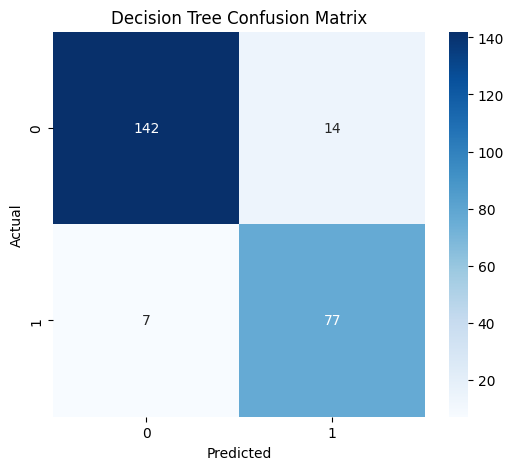

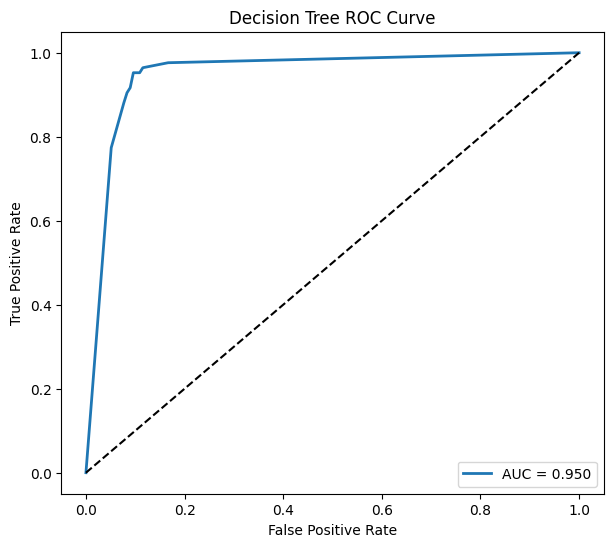

ROC-AUC Score : 0.9501

5-Fold Cross Validation Scores
[0.925      0.9125     0.89166667 0.875      0.9375    ]

Mean Accuracy : 0.9083
Standard Deviation : 0.0225


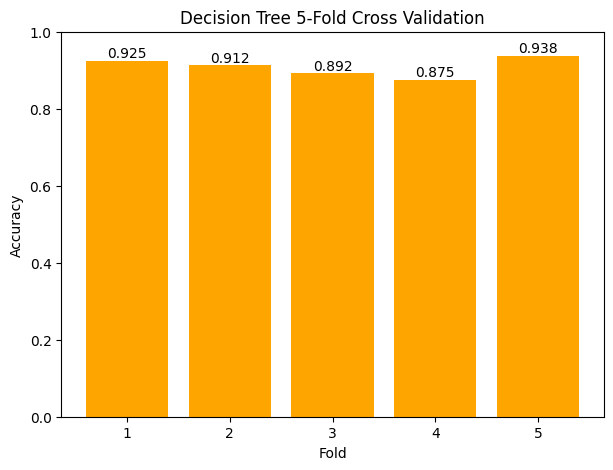


Feature Importance
            Feature  Importance
6               evi    0.460043
12   moisture_index    0.179867
11   canopy_density    0.164219
0         ndvi_mean    0.083924
3          ndvi_max    0.062623
4             gndvi    0.025570
5              savi    0.008885
14           grid_y    0.008128
9   nir_reflectance    0.006740
1          ndvi_std    0.000000
2          ndvi_min    0.000000
10  soil_brightness    0.000000
8        red_edge_2    0.000000
7        red_edge_1    0.000000
13           grid_x    0.000000


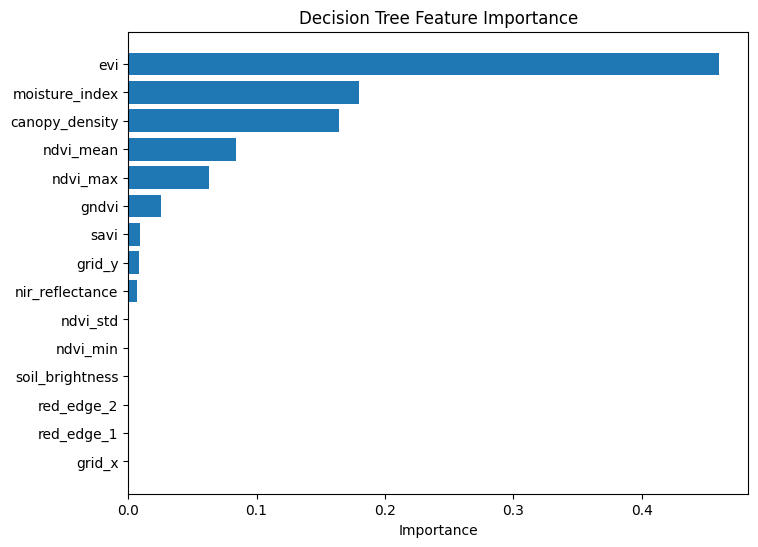

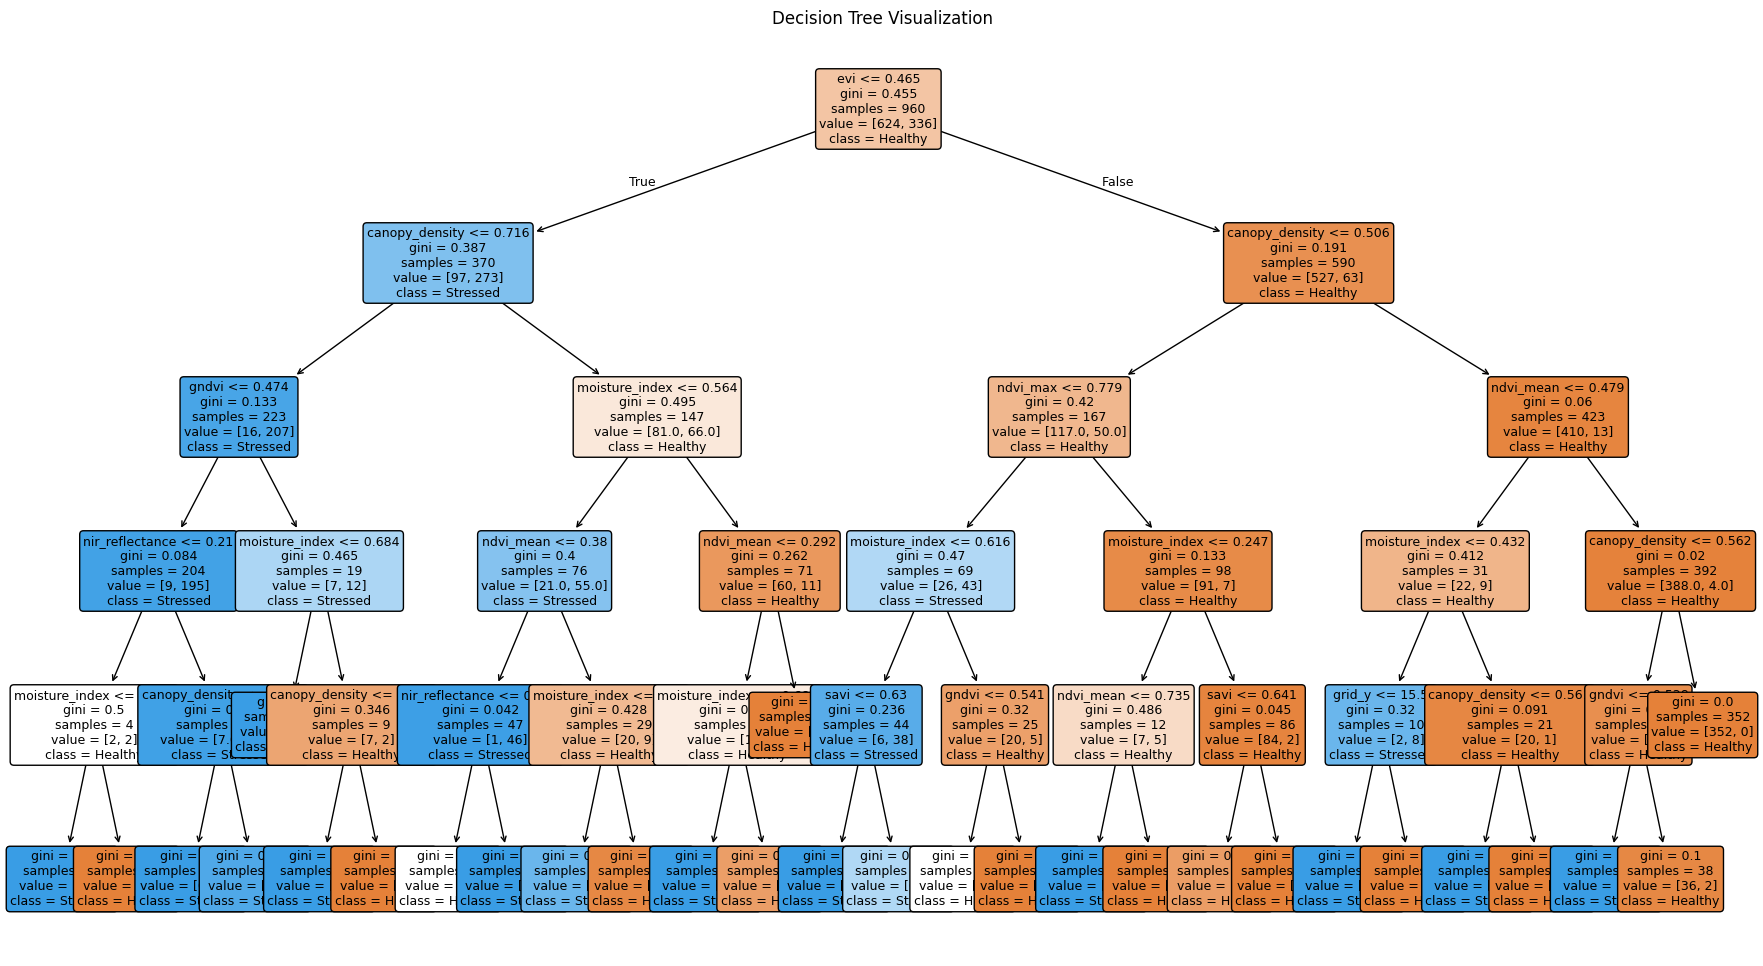

DECISION TREE MODEL EVALUATION COMPLETED


In [ ]:
# ==========================================================
# DECISION TREE CLASSIFIER - COMPLETE MODEL EVALUATION
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score

# ==========================================================
# Train Decision Tree Model
# ==========================================================

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt_model.fit(x_train, y_train)

# ==========================================================
# Predictions
# ==========================================================

y_pred_dt = dt_model.predict(x_test)
y_prob_dt = dt_model.predict_proba(x_test)[:,1]

# ==========================================================
# Performance Metrics
# ==========================================================

accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt, average='weighted')
recall = recall_score(y_test, y_pred_dt, average='weighted')
f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("="*60)
print("DECISION TREE MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_dt))

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================================
# ROC Curve
# ==========================================================

fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob_dt)
roc_auc = roc_auc_score(y_test_encoded, y_prob_dt)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")

plt.legend()

plt.show()

print(f"ROC-AUC Score : {roc_auc:.4f}")

# ==========================================================
# 5-Fold Cross Validation
# ==========================================================

cv_scores = cross_val_score(
    dt_model,
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print("\n5-Fold Cross Validation Scores")
print(cv_scores)

print(f"\nMean Accuracy : {cv_scores.mean():.4f}")
print(f"Standard Deviation : {cv_scores.std():.4f}")

# ==========================================================
# Cross Validation Plot
# ==========================================================

plt.figure(figsize=(7,5))

plt.bar(
    range(1,6),
    cv_scores,
    color='orange'
)

plt.title("Decision Tree 5-Fold Cross Validation")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

for i, score in enumerate(cv_scores):
    plt.text(
        i+1,
        score,
        f"{score:.3f}",
        ha='center',
        va='bottom'
    )

plt.ylim(0,1)

plt.show()

# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)

# ==========================================================
# Feature Importance Plot
# ==========================================================

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# ==========================================================
# Decision Tree Visualization
# ==========================================================

plt.figure(figsize=(22,12))

plot_tree(
    dt_model,
    feature_names=x.columns,
    class_names=y.unique(),
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Visualization")

plt.show()

print("="*60)
print("DECISION TREE MODEL EVALUATION COMPLETED")
print("="*60)

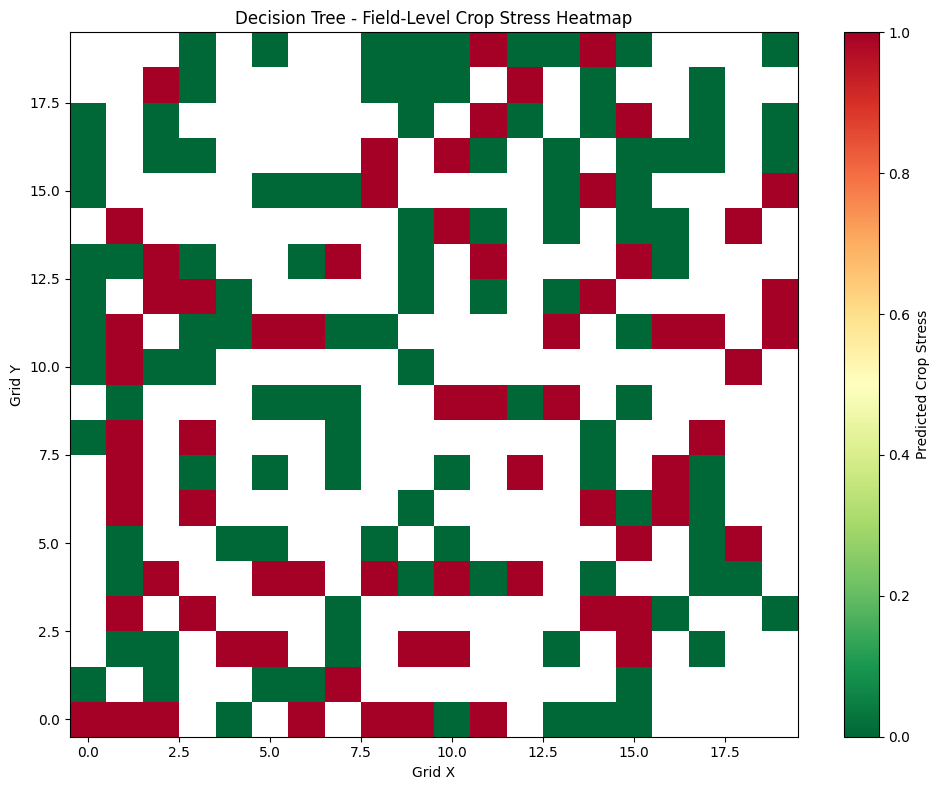

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Predict crop stress using Decision Tree
predictions = dt_model.predict(x_test)

# Create a copy of the x_test dataset
heatmap_data = x_test.copy()

# Add predictions
heatmap_data["Predicted_Stress"] = predictions

# Convert string labels to numerical values for heatmap
heatmap_data["Predicted_Stress_Numeric"] = heatmap_data["Predicted_Stress"].map({
    "Healthy": 0,
    "Stressed": 1
})

# Create an empty grid
grid_size_x = int(heatmap_data["grid_x"].max()) + 1
grid_size_y = int(heatmap_data["grid_y"].max()) + 1

field_grid = np.full((grid_size_y, grid_size_x), np.nan)

# Fill grid with predicted stress values
for _, row in heatmap_data.iterrows():
    x_coord = int(row["grid_x"])
    y_coord = int(row["grid_y"])
    field_grid[y_coord, x_coord] = row["Predicted_Stress_Numeric"]

# Plot Heatmap
plt.figure(figsize=(10,8))

plt.imshow(
    field_grid,
    cmap="RdYlGn_r",
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Predicted Crop Stress")

plt.title("Decision Tree - Field-Level Crop Stress Heatmap")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")

plt.tight_layout()
plt.show()

# RANDOM FOREST

RANDOM FOREST MODEL PERFORMANCE
Accuracy : 0.9250
Precision: 0.9247
Recall   : 0.9250
F1-Score : 0.9248

Classification Report

              precision    recall  f1-score   support

     Healthy       0.94      0.95      0.94       156
    Stressed       0.90      0.88      0.89        84

    accuracy                           0.93       240
   macro avg       0.92      0.91      0.92       240
weighted avg       0.92      0.93      0.92       240



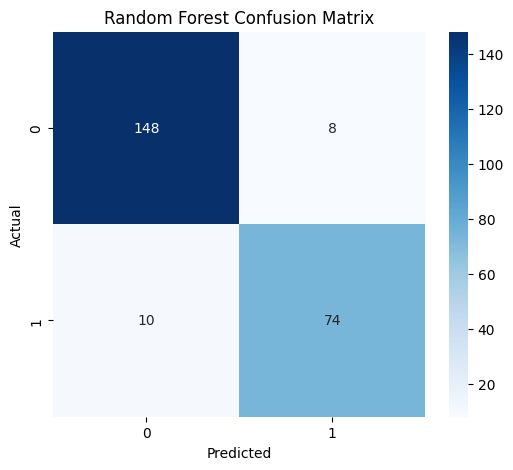

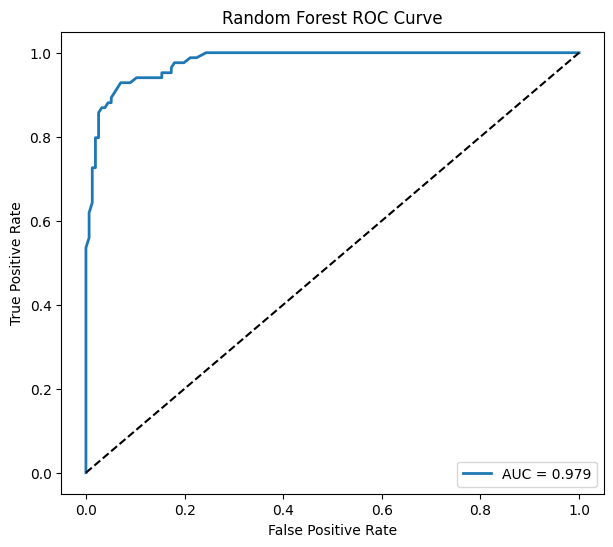

ROC-AUC Score : 0.9794

5-Fold Cross Validation Scores
[0.925      0.94166667 0.9        0.92916667 0.9375    ]

Mean Accuracy : 0.9267
Standard Deviation : 0.0146


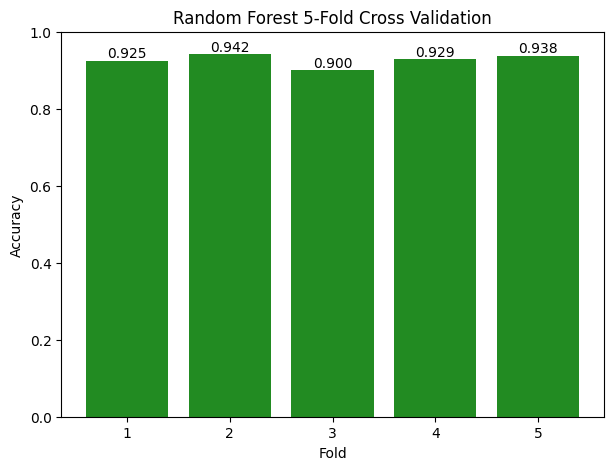


Feature Importance
            Feature  Importance
11   canopy_density    0.144314
0         ndvi_mean    0.133599
6               evi    0.127459
4             gndvi    0.108291
2          ndvi_min    0.095707
12   moisture_index    0.089327
5              savi    0.086379
3          ndvi_max    0.083096
10  soil_brightness    0.021710
9   nir_reflectance    0.021002
7        red_edge_1    0.020732
1          ndvi_std    0.020582
8        red_edge_2    0.019888
13           grid_x    0.014064
14           grid_y    0.013851


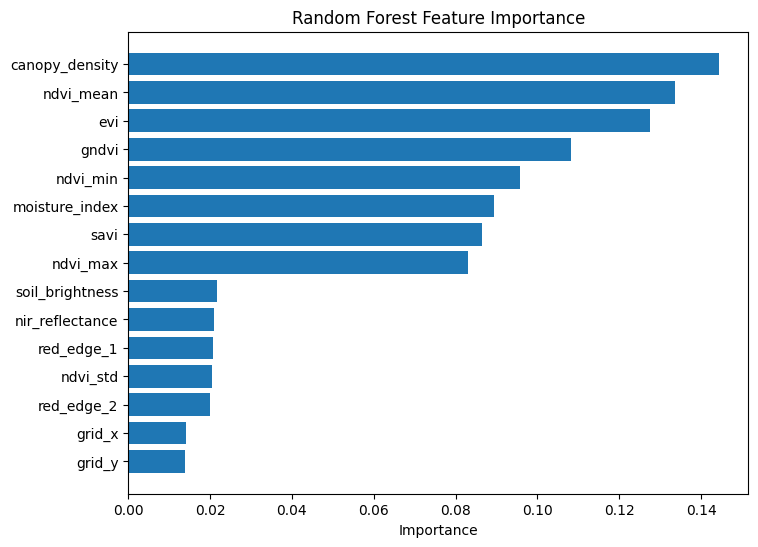

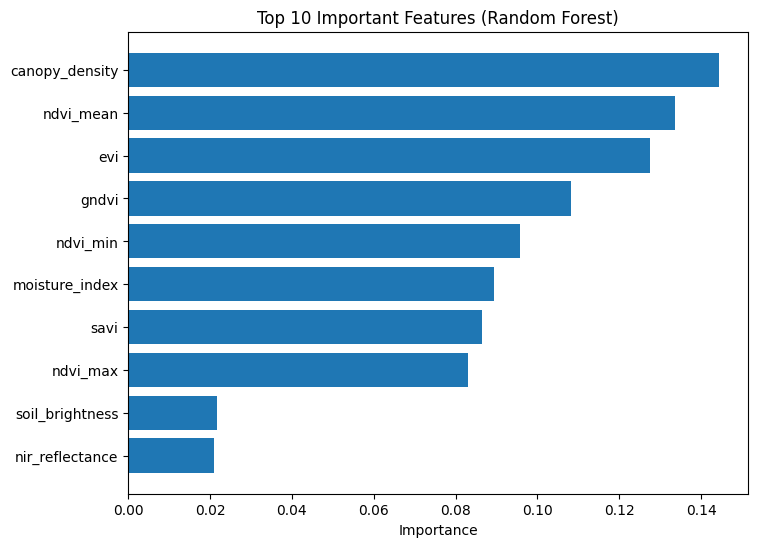

RANDOM FOREST MODEL EVALUATION COMPLETED


In [ ]:
# ==========================================================
# RANDOM FOREST CLASSIFIER - COMPLETE MODEL EVALUATION
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score

# ==========================================================
# Train Random Forest Model
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)

# ==========================================================
# Predictions
# ==========================================================

y_pred_rf = rf_model.predict(x_test)
y_prob_rf = rf_model.predict_proba(x_test)[:,1]

# ==========================================================
# Performance Metrics
# ==========================================================

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("="*60)
print("RANDOM FOREST MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================================
# ROC Curve
# ==========================================================

fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob_rf)
roc_auc = roc_auc_score(y_test_encoded, y_prob_rf)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

print(f"ROC-AUC Score : {roc_auc:.4f}")

# ==========================================================
# 5-Fold Cross Validation
# ==========================================================

cv_scores = cross_val_score(
    rf_model,
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print("\n5-Fold Cross Validation Scores")
print(cv_scores)

print(f"\nMean Accuracy : {cv_scores.mean():.4f}")
print(f"Standard Deviation : {cv_scores.std():.4f}")

# ==========================================================
# Cross Validation Plot
# ==========================================================

plt.figure(figsize=(7,5))

plt.bar(
    range(1,6),
    cv_scores,
    color='forestgreen'
)

plt.title("Random Forest 5-Fold Cross Validation")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

for i, score in enumerate(cv_scores):
    plt.text(
        i+1,
        score,
        f"{score:.3f}",
        ha='center',
        va='bottom'
    )

plt.ylim(0,1)

plt.show()

# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)

# ==========================================================
# Feature Importance Plot
# ==========================================================

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# ==========================================================
# Top 10 Important Features
# ==========================================================

top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.title("Top 10 Important Features (Random Forest)")

plt.gca().invert_yaxis()

plt.show()

print("="*60)
print("RANDOM FOREST MODEL EVALUATION COMPLETED")
print("="*60)

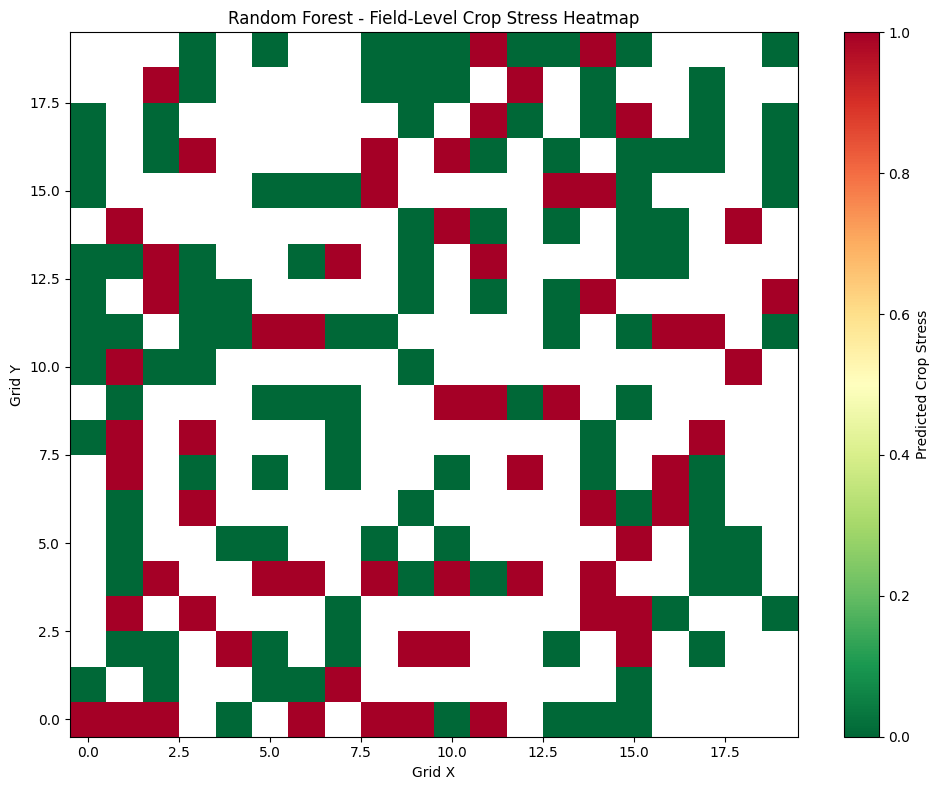

In [ ]:
# ==========================================
# Random Forest Field-Level Crop Stress Heatmap
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# Predict crop stress using Random Forest
rf_predictions = rf_model.predict(x_test)

# Create a copy of the x_test dataset
heatmap_data = x_test.copy()

# Add predicted crop stress
heatmap_data["Predicted_Stress"] = rf_predictions

# Convert string labels to numerical values for heatmap
heatmap_data["Predicted_Stress_Numeric"] = heatmap_data["Predicted_Stress"].map({
    "Healthy": 0,
    "Stressed": 1
})

# Determine grid dimensions
grid_x_size = int(heatmap_data["grid_x"].max()) + 1
grid_y_size = int(heatmap_data["grid_y"].max()) + 1

# Initialize field grid
field_grid = np.full((grid_y_size, grid_x_size), np.nan)

# Fill the grid with predictions
for _, row in heatmap_data.iterrows():
    x = int(row["grid_x"])
    y = int(row["grid_y"])
    field_grid[y, x] = row["Predicted_Stress_Numeric"]

# Plot the heatmap
plt.figure(figsize=(10,8))

plt.imshow(
    field_grid,
    cmap="RdYlGn_r",
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Predicted Crop Stress")

plt.title("Random Forest - Field-Level Crop Stress Heatmap")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")

plt.tight_layout()
plt.show()

# 5 FOLD CROSS VALIDATION STOCHASTIC

STOCHASTIC GRADIENT DESCENT MODEL PERFORMANCE
Accuracy  : 0.9833
Precision : 0.9841
Recall    : 0.9833
F1-Score  : 0.9834

Classification Report

              precision    recall  f1-score   support

     Healthy       1.00      0.97      0.99       156
    Stressed       0.95      1.00      0.98        84

    accuracy                           0.98       240
   macro avg       0.98      0.99      0.98       240
weighted avg       0.98      0.98      0.98       240



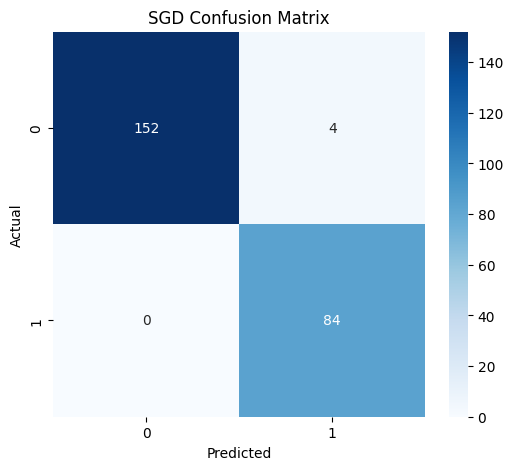

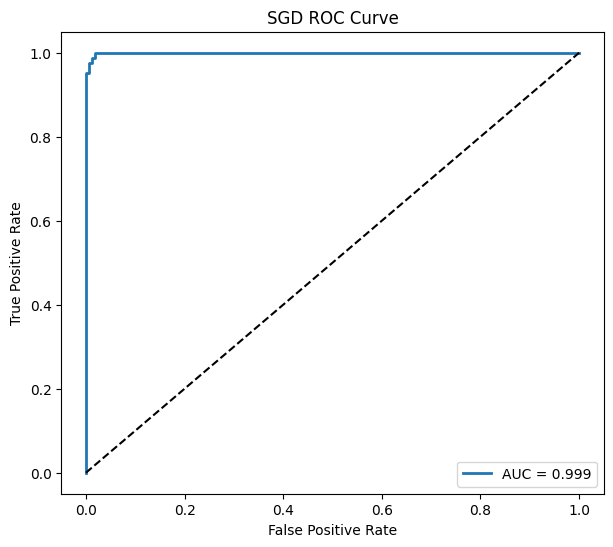

ROC-AUC Score : 0.9995

5-Fold Cross Validation Scores
[0.99583333 0.97916667 0.975      0.97916667 0.98333333]

Mean Accuracy      : 0.9825
Standard Deviation : 0.0072


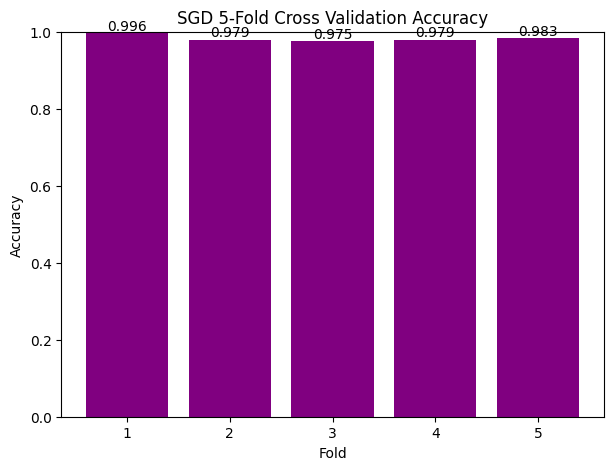


Feature Importance
            Feature  Coefficient
0         ndvi_mean   -17.749067
11   canopy_density   -16.973689
12   moisture_index   -13.824248
3          ndvi_max    -3.304021
5              savi    -2.735345
2          ndvi_min    -1.946588
4             gndvi    -1.864645
6               evi    -1.452937
13           grid_x     0.634475
14           grid_y    -0.496300
8        red_edge_2     0.438938
10  soil_brightness     0.297946
9   nir_reflectance     0.277755
7        red_edge_1     0.252981
1          ndvi_std    -0.126335


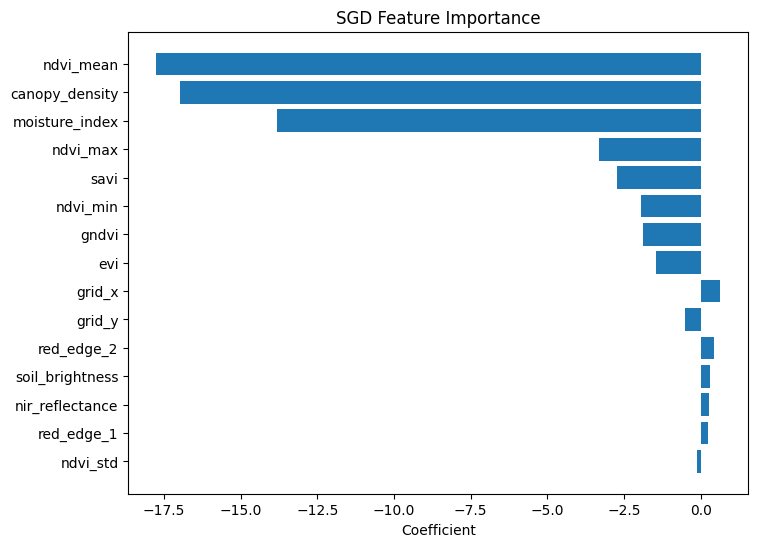

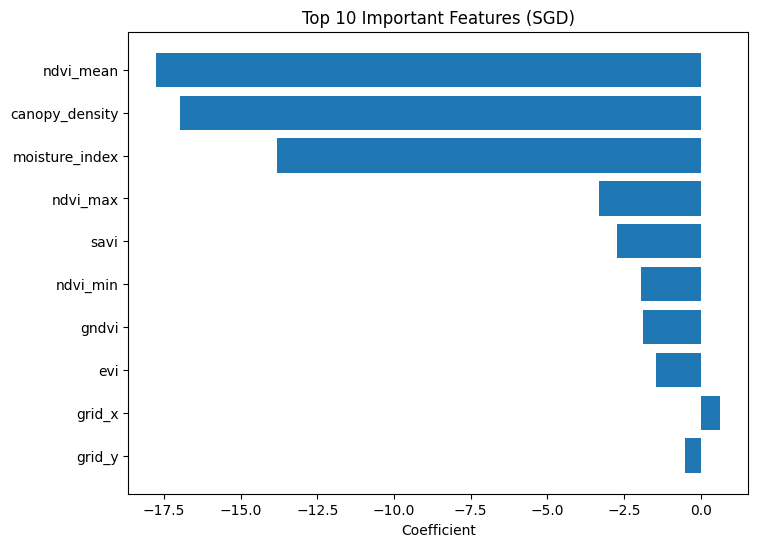

SGD MODEL EVALUATION COMPLETED SUCCESSFULLY


In [ ]:
# ==========================================================
# STOCHASTIC GRADIENT DESCENT (SGD) - COMPLETE MODEL
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score

# Re-load data and redefine x, y to ensure correctness
input_file="crop_data.csv"
df=pd.read_csv(input_file)
df.columns=['ndvi_mean','ndvi_std','ndvi_min','ndvi_max','gndvi','savi','evi','red_edge_1','red_edge_2','nir_reflectance','soil_brightness','canopy_density','moisture_index','grid_x','grid_y','crop_health_label']
x=df.drop("crop_health_label", axis=1)
y=df["crop_health_label"]

# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Scale the complete dataset for Cross Validation
x_scaled = scaler.fit_transform(x)

# ==========================================================
# Train SGD Classifier
# ==========================================================

sgd_model = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

sgd_model.fit(x_train_scaled, y_train)

# ==========================================================
# Predictions
# ==========================================================

y_pred_sgd = sgd_model.predict(x_test_scaled)
y_prob_sgd = sgd_model.predict_proba(x_test_scaled)[:,1]

# ==========================================================
# Performance Metrics
# ==========================================================

accuracy = accuracy_score(y_test, y_pred_sgd)
precision = precision_score(y_test, y_pred_sgd, average='weighted')
recall = recall_score(y_test, y_pred_sgd, average='weighted')
f1 = f1_score(y_test, y_pred_sgd, average='weighted')

print("="*60)
print("STOCHASTIC GRADIENT DESCENT MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_sgd))

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred_sgd)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("SGD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================================
# ROC Curve
# ==========================================================

fpr, tpr, _ = roc_curve(y_test_encoded, y_prob_sgd)
roc_auc = roc_auc_score(y_test_encoded, y_prob_sgd)

plt.figure(figsize=(7,6))

plt.plot(fpr,
         tpr,
         linewidth=2,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SGD ROC Curve")

plt.legend()

plt.show()

print(f"ROC-AUC Score : {roc_auc:.4f}")

# ==========================================================
# 5-Fold Cross Validation
# ==========================================================

cv_scores = cross_val_score(
    SGDClassifier(
        loss='log_loss',
        penalty='l2',
        alpha=0.0001,
        max_iter=1000,
        tol=1e-3,
        random_state=42
    ),
    x_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("\n5-Fold Cross Validation Scores")
print(cv_scores)

print(f"\nMean Accuracy      : {cv_scores.mean():.4f}")
print(f"Standard Deviation : {cv_scores.std():.4f}")

# ==========================================================
# Cross Validation Plot
# ==========================================================

plt.figure(figsize=(7,5))

plt.bar(
    range(1,6),
    cv_scores,
    color='purple'
)

plt.title("SGD 5-Fold Cross Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

for i, score in enumerate(cv_scores):
    plt.text(
        i+1,
        score,
        f"{score:.3f}",
        ha='center',
        va='bottom'
    )

plt.ylim(0,1)

plt.show()

# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": sgd_model.coef_[0]
})

importance = importance.reindex(
    importance["Coefficient"].abs().sort_values(ascending=False).index
)

print("\nFeature Importance")
print(importance)

# ==========================================================
# Feature Importance Plot
# ==========================================================

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Coefficient"]
)

plt.xlabel("Coefficient")
plt.title("SGD Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# ==========================================================
# Top 10 Important Features
# ==========================================================

top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Coefficient"]
)

plt.xlabel("Coefficient")
plt.title("Top 10 Important Features (SGD)")

plt.gca().invert_yaxis()

plt.show()

print("="*60)
print("SGD MODEL EVALUATION COMPLETED SUCCESSFULLY")
print("="*60)

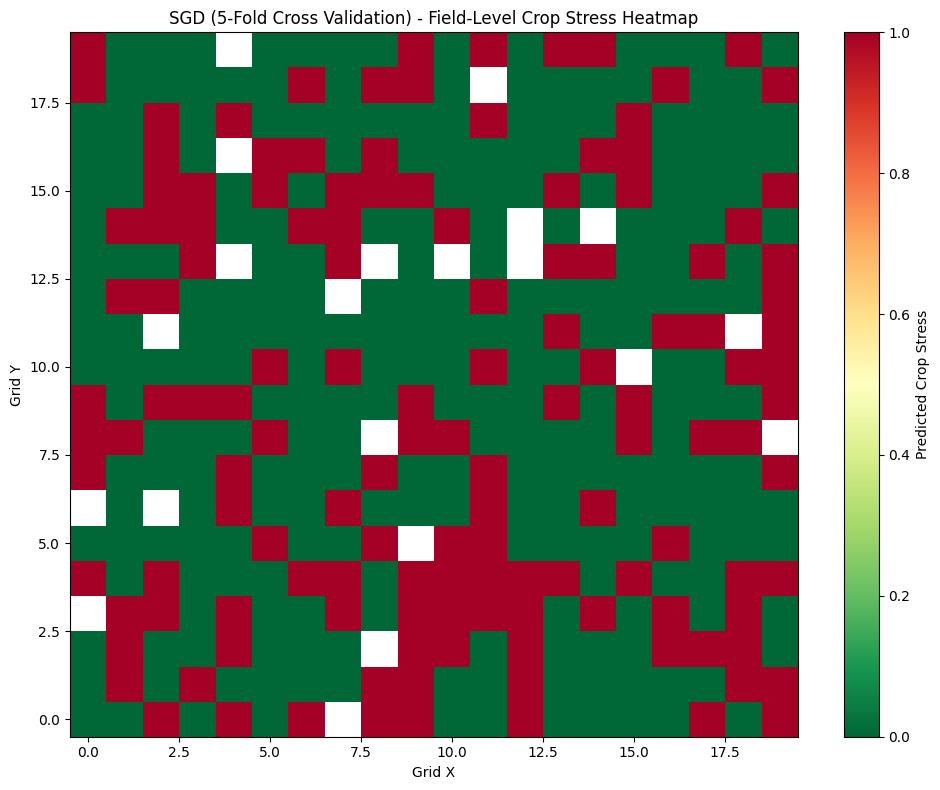

In [ ]:
# ==========================================
# SGD (5-Fold Cross Validation) Field-Level Crop Stress Heatmap
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# Predict crop stress using the trained SGD model
sgd_predictions = sgd_model.predict(x_scaled)

# Create a copy of the original dataset
heatmap_data = df.copy()

# Add predicted stress values
heatmap_data["Predicted_Stress"] = sgd_predictions

# Convert string labels to numerical values for heatmap
heatmap_data["Predicted_Stress_Numeric"] = heatmap_data["Predicted_Stress"].map({
    "Healthy": 0,
    "Stressed": 1
})

# Determine grid dimensions
grid_x_size = int(heatmap_data["grid_x"].max()) + 1
grid_y_size = int(heatmap_data["grid_y"].max()) + 1

# Create an empty grid
field_grid = np.full((grid_y_size, grid_x_size), np.nan)

# Populate the grid with predictions
for _, row in heatmap_data.iterrows():
    x = int(row["grid_x"])
    y = int(row["grid_y"])
    field_grid[y, x] = row["Predicted_Stress_Numeric"]

# Plot the heatmap
plt.figure(figsize=(10,8))

plt.imshow(
    field_grid,
    cmap="RdYlGn_r",
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Predicted Crop Stress")

plt.title("SGD (5-Fold Cross Validation) - Field-Level Crop Stress Heatmap")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")

plt.tight_layout()
plt.show()

MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1-Score  5-Fold CV
0  Logistic Regression  0.954167   0.954075  0.954167  0.954103   0.962500
1        Decision Tree  0.912500   0.915617  0.912500  0.913246   0.908333
2        Random Forest  0.925000   0.924714  0.925000  0.924787   0.926667
3                  SGD  0.983333   0.984091  0.983333  0.983419   0.982500


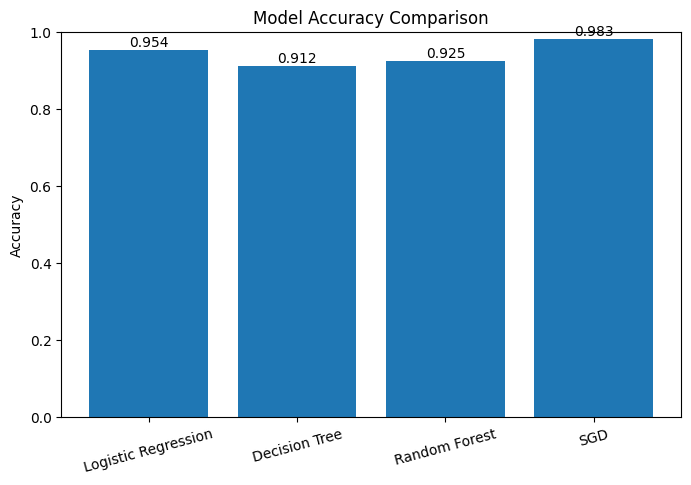

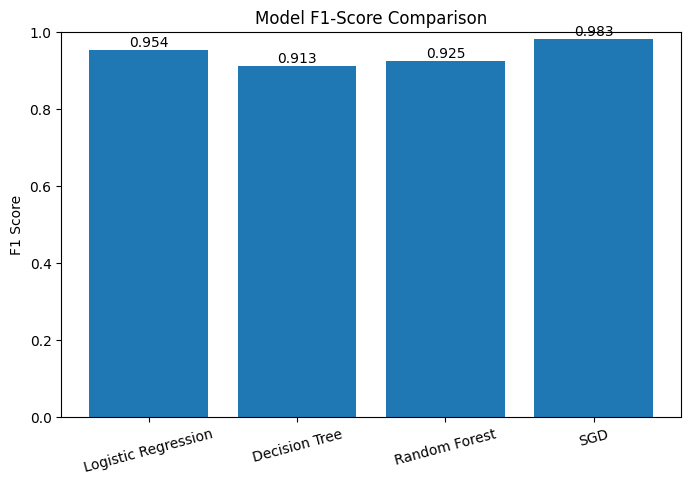

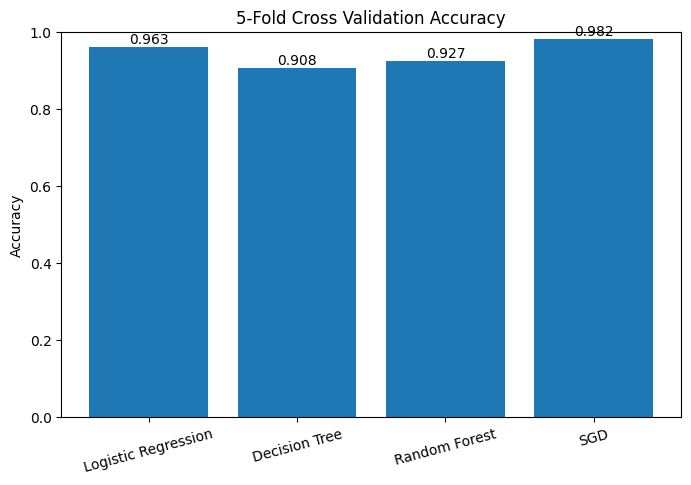



BEST MODEL
Model             SGD
Accuracy     0.983333
Precision    0.984091
Recall       0.983333
F1-Score     0.983419
5-Fold CV      0.9825
Name: 3, dtype: object

Best Model: SGD
Accuracy : 0.9833
F1 Score : 0.9834
5-Fold CV: 0.9825


In [ ]:
# ==========================================================
# MODEL COMPARISON
# Logistic Regression vs Decision Tree
# Random Forest vs SGD
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import cross_val_score

# ==========================================================
# Calculate Metrics
# ==========================================================

lr_accuracy = accuracy_score(y_test, preds)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
sgd_accuracy = accuracy_score(y_test, y_pred_sgd)

lr_precision = precision_score(y_test, preds, average='weighted')
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
sgd_precision = precision_score(y_test, y_pred_sgd, average='weighted')

lr_recall = recall_score(y_test, preds, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
sgd_recall = recall_score(y_test, y_pred_sgd, average='weighted')

lr_f1 = f1_score(y_test, preds, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
sgd_f1 = f1_score(y_test, y_pred_sgd, average='weighted')

# ==========================================================
# 5-Fold Cross Validation
# ==========================================================

lr_cv = cross_val_score(model, x, y, cv=5, scoring='accuracy').mean()

dt_cv = cross_val_score(dt_model, x, y, cv=5, scoring='accuracy').mean()

rf_cv = cross_val_score(rf_model, x, y, cv=5, scoring='accuracy').mean()

sgd_cv = cross_val_score(
    sgd_model,
    x_scaled,
    y,
    cv=5,
    scoring='accuracy'
).mean()

# ==========================================================
# Comparison Table
# ==========================================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SGD"
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        sgd_accuracy
    ],

    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision,
        sgd_precision
    ],

    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall,
        sgd_recall
    ],

    "F1-Score": [
        lr_f1,
        dt_f1,
        rf_f1,
        sgd_f1
    ],

    "5-Fold CV": [
        lr_cv,
        dt_cv,
        rf_cv,
        sgd_cv
    ]
})

print("="*75)
print("MODEL COMPARISON")
print("="*75)

print(results)

# ==========================================================
# Accuracy Comparison
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

for i, value in enumerate(results["Accuracy"]):
    plt.text(i, value, f"{value:.3f}", ha='center', va='bottom')

plt.ylim(0,1)

plt.show()

# ==========================================================
# F1 Score Comparison
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["F1-Score"]
)

plt.title("Model F1-Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)

for i, value in enumerate(results["F1-Score"]):
    plt.text(i, value, f"{value:.3f}", ha='center', va='bottom')

plt.ylim(0,1)

plt.show()

# ==========================================================
# Cross Validation Comparison
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["5-Fold CV"]
)

plt.title("5-Fold Cross Validation Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

for i, value in enumerate(results["5-Fold CV"]):
    plt.text(i, value, f"{value:.3f}", ha='center', va='bottom')

plt.ylim(0,1)

plt.show()

# ==========================================================
# Best Model
# ==========================================================

best_model = results.loc[results["Accuracy"].idxmax()]

print("\n")
print("="*75)
print("BEST MODEL")
print("="*75)

print(best_model)

print("\nBest Model:", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"],4))
print("F1 Score :", round(best_model["F1-Score"],4))
print("5-Fold CV:", round(best_model["5-Fold CV"],4))

# Task 4

## Drone & Agronomy Interpretation:
Drone Inspection Strategy Based on Model Predictions

The machine learning models were used to classify each field location as either Healthy or Stressed using vegetation indices extracted from drone multispectral imagery. A field-level stress heatmap was generated by aggregating these predictions into spatial grids.

Interpretation of Dataset Features
NDVI (Normalized Difference Vegetation Index): Lower values indicate poor vegetation vigor and possible crop stress.
GNDVI (Green NDVI): Used to identify nitrogen deficiency and chlorophyll content.
SAVI (Soil Adjusted Vegetation Index): Reduces soil background effects and indicates vegetation health.
EVI (Enhanced Vegetation Index): Detects dense vegetation and improves sensitivity in high biomass regions.
Red Edge Index: Detects early crop stress before visible symptoms appear.
Canopy Density: Lower canopy density indicates poor plant growth or damaged crops.
Moisture Index: Lower values indicate water stress and insufficient soil moisture.
Drone Inspection Recommendations
Healthy Areas

Areas with high NDVI, GNDVI, SAVI, EVI, canopy density, and moisture index values indicate healthy crop growth.

Recommended Action

Continue routine drone monitoring every 7–14 days.
Maintain the current irrigation and fertilizer schedule.
No immediate intervention is required.
Moderate Stress Areas

Areas showing slightly lower vegetation indices may indicate the early stages of stress.

Recommended Action

Schedule drone flights every 3–5 days.
Inspect for:
Nutrient deficiency
Uneven irrigation
Early pest infestation
Weed growth
High Stress Areas

Areas with low NDVI, GNDVI, EVI, canopy density, and moisture index values represent severely stressed crops.

Recommended Action

Perform immediate drone inspection using high-resolution multispectral imaging.
Conduct field verification.
Apply:
Targeted irrigation
Nitrogen fertilizer
Pest and disease control measures


# Task 5

## Reflection: Limitations and Future Improvements Using Real-World Data

Limitations

Although the developed crop health monitoring system produced accurate predictions, several limitations exist.

The dataset consists of processed vegetation indices rather than raw multispectral drone images.

Environmental variables such as rainfall, temperature, humidity, soil type, and wind conditions were not included.

The dataset represents observations from a limited period and does not capture seasonal crop variations.

Ground-truth field measurements were unavailable to verify every predicted stress region.

The dataset size is relatively small compared with commercial agricultural datasets, which may limit model generalization.
Model Performance Reflection

Four machine learning algorithms were evaluated.

Model	Performance Summary

Logistic Regression	High accuracy with good interpretability.

Decision Tree	Easy to interpret but more prone to overfitting.

Random Forest	Better handling of nonlinear relationships than a single Decision Tree.

Stochastic Gradient Descent (SGD)	Best overall performance with the highest accuracy and F1-score.

Based on the experimental results, the SGD Classifier provided the best classification performance for this dataset because it effectively separated healthy and stressed crop samples using the vegetation indices.

Proposed Improvements

The system can be further improved by:

Collecting raw multispectral drone images instead of only vegetation indices.

Performing repeated drone surveys throughout the crop growth cycle.

Integrating weather data such as rainfall, temperature, and humidity.

Including soil moisture sensor data from IoT devices.

Collecting ground-truth crop health observations for better validation.

Evaluating advanced AI models such as XGBoost, LightGBM, CNNs, and Vision Transformers.

Developing a real-time drone monitoring system capable of automatically generating stress alerts and prescription maps.

Reflection Summary

This capstone demonstrates that drone-derived multispectral vegetation indices can be effectively combined with machine learning to detect crop stress and support precision agriculture. The generated stress heatmaps help identify affected regions, enabling farmers to focus inspections and interventions where they are most needed. Among the evaluated models, the Stochastic Gradient Descent (SGD) classifier achieved the best overall performance, providing the highest classification accuracy and strong precision, recall, and F1-score for distinguishing healthy and stressed crops. Future improvements involving real-time drone imagery, IoT sensors, weather information, and advanced AI models can further enhance prediction accuracy and decision-making in agricultural monitoring.